In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [ ]:
train_data = datasets.CIFAR100(root='cifar_d',train=True,download=True, transform=transforms.ToTensor())
test_data = datasets.CIFAR100(root='cifar_d',train=False,download=True, transform=transforms.ToTensor())

100%|██████████| 169M/169M [00:13<00:00, 12.6MB/s]


In [ ]:
classes = train_data.classes
classes

['apple',
 'aquarium_fish',
 'baby',
 'bear',
 'beaver',
 'bed',
 'bee',
 'beetle',
 'bicycle',
 'bottle',
 'bowl',
 'boy',
 'bridge',
 'bus',
 'butterfly',
 'camel',
 'can',
 'castle',
 'caterpillar',
 'cattle',
 'chair',
 'chimpanzee',
 'clock',
 'cloud',
 'cockroach',
 'couch',
 'crab',
 'crocodile',
 'cup',
 'dinosaur',
 'dolphin',
 'elephant',
 'flatfish',
 'forest',
 'fox',
 'girl',
 'hamster',
 'house',
 'kangaroo',
 'keyboard',
 'lamp',
 'lawn_mower',
 'leopard',
 'lion',
 'lizard',
 'lobster',
 'man',
 'maple_tree',
 'motorcycle',
 'mountain',
 'mouse',
 'mushroom',
 'oak_tree',
 'orange',
 'orchid',
 'otter',
 'palm_tree',
 'pear',
 'pickup_truck',
 'pine_tree',
 'plain',
 'plate',
 'poppy',
 'porcupine',
 'possum',
 'rabbit',
 'raccoon',
 'ray',
 'road',
 'rocket',
 'rose',
 'sea',
 'seal',
 'shark',
 'shrew',
 'skunk',
 'skyscraper',
 'snail',
 'snake',
 'spider',
 'squirrel',
 'streetcar',
 'sunflower',
 'sweet_pepper',
 'table',
 'tank',
 'telephone',
 'television',
 'tig

In [ ]:
len(classes)

100

In [ ]:
train = DataLoader(train_data,batch_size=64,shuffle=True)
test = DataLoader(test_data,batch_size=64, shuffle=True)

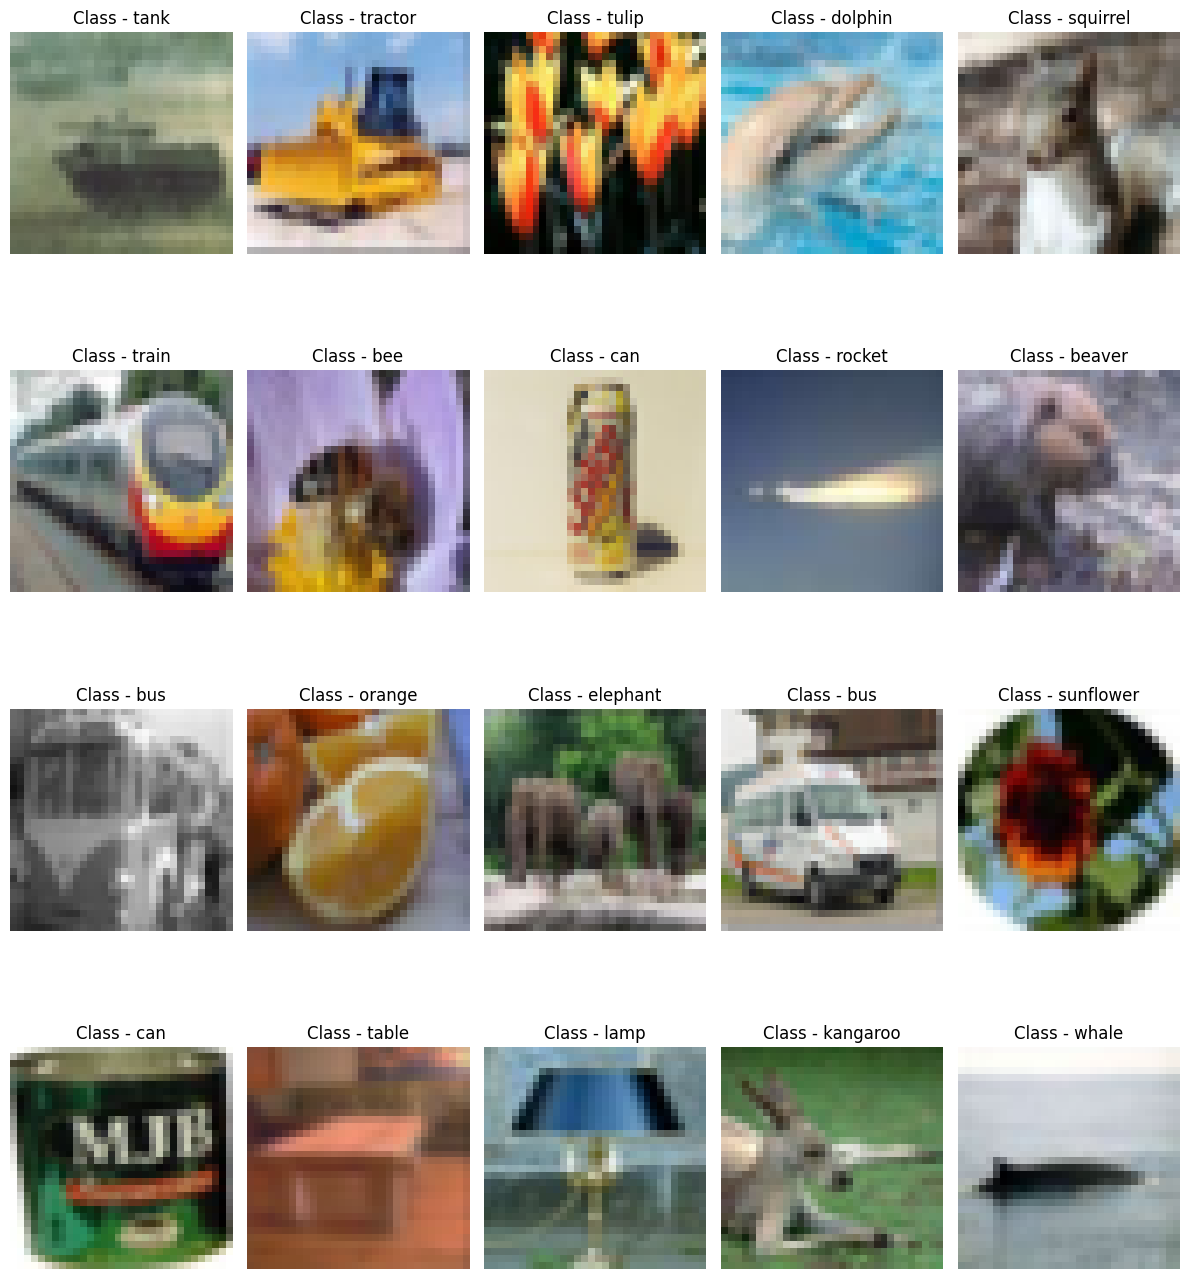

In [ ]:
image, label = next(iter(train))
plt.figure(figsize=(12,16))
for i in range(20):
    plt.subplot(4,5,i+1)
    plt.imshow(image[i].permute(1, 2, 0))
    plt.title(f'Class - {classes[label[i]]}')
    plt.axis('off')
    plt.tight_layout()
plt.show()

In [ ]:
import torch
import torch.nn as nn

class CifarBetter(nn.Module):
    def __init__(self):
        super().__init__()

        self.first = nn.Sequential(
            # 32x32 -> 16x16
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # 16x16 -> 8x8
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # 8x8 -> 4x4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((4, 4))
        )

        self.second = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 1024),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(512, 100)
        )

    def forward(self, x):
        x = self.first(x)
        x = self.second(x)
        return x

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [ ]:
model = CifarCheck().to(device)

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
for epoch in range(100):
  model.train()
  total_loss = 0
  for x_batch, y_batch in train:
    x_batch, y_batch = x_batch.to(device), y_batch.to(device)

    y_pred = model(x_batch)
    loss = loss_fn(y_pred, y_batch)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_loss += loss.item()

  print(f'Epoch {epoch + 1}, losses: {round(total_loss, 2)}')

Epoch 1, losses: 3005.86
Epoch 2, losses: 2558.24
Epoch 3, losses: 2341.29
Epoch 4, losses: 2200.09
Epoch 5, losses: 2098.52
Epoch 6, losses: 2006.3
Epoch 7, losses: 1933.43
Epoch 8, losses: 1865.62
Epoch 9, losses: 1808.66
Epoch 10, losses: 1744.49
Epoch 11, losses: 1688.4
Epoch 12, losses: 1641.54
Epoch 13, losses: 1588.98
Epoch 14, losses: 1550.38
Epoch 15, losses: 1505.39
Epoch 16, losses: 1470.76
Epoch 17, losses: 1435.04
Epoch 18, losses: 1398.9
Epoch 19, losses: 1366.33
Epoch 20, losses: 1333.61
Epoch 21, losses: 1299.69
Epoch 22, losses: 1278.37
Epoch 23, losses: 1248.28
Epoch 24, losses: 1225.37
Epoch 25, losses: 1197.81
Epoch 26, losses: 1171.26
Epoch 27, losses: 1152.69
Epoch 28, losses: 1124.44
Epoch 29, losses: 1105.5
Epoch 30, losses: 1086.19
Epoch 31, losses: 1067.11
Epoch 32, losses: 1040.78
Epoch 33, losses: 1028.03
Epoch 34, losses: 1008.22
Epoch 35, losses: 996.11
Epoch 36, losses: 980.37
Epoch 37, losses: 958.12
Epoch 38, losses: 941.95
Epoch 39, losses: 940.1
Epoch

In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
  for x_batch, y_batch in test:
    x_batch, y_batch = x_batch.to(device), y_batch.to(device)
    y_pred = model(x_batch)
    predicted = torch.argmax(y_pred, dim=1)
    total += y_batch.size(0)
    correct += (predicted == y_batch).sum().item()

accuracy = 100 * correct / total
print(f'Accuracy of the test data model: {round(accuracy, 2)}%')

Accuracy of the test data model: 45.34%


In [ ]:
torch.save(model.state_dict(), 'cifar100_model.pth')

In [ ]:
class CifarClassifaction2(nn.Module):
  def __init__(self):
    super().__init__()

    self.first = nn.Sequential(
        nn.Conv2d(3, 32, kernel_size=3, padding=1),#32x32
        nn.ReLU(),
        nn.MaxPool2d(2)
    )

    self.second = nn.Sequential(
        nn.Flatten(),
        nn.Linear(32 * 16 * 16, 64),
        nn.ReLU(),
        nn.Linear(64, 10)
    )

  def forward(self, image):
    image = self.first(image)
    image = self.second(image)
    return image